<div align = "right">
12 / 05 / 26
<div style = "height: 20px;"></div>
<span style = "color:orange"> <strong>Reconocimiento de Patrones </strong></span>
<style>div[align = "right"]{font-family: 'Montserrat', sans-serif;}</style></div>

<h1 style = "color: orange"><strong> Práctica 4: Clasificadores</strong></h1>

In [2]:
# Bibliotecas
import os
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image
from imblearn.over_sampling import SMOTE
from IPython.display import HTML, Video, display
from ydata_profiling import ProfileReport
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [3]:
RUTA_IMG = '/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img'
RUTA_SANBORNS = '/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Auxiliares/sanborns.png'

os.makedirs(RUTA_IMG, exist_ok = True)

def guardar_figura(nombre):
    """Guarda la figura activa en RUTA_IMG con el nombre dado (.png)."""
    ruta = os.path.join(RUTA_IMG, nombre)
    plt.savefig(ruta, dpi = 300, bbox_inches = 'tight')
    print(f'{ruta}')

## 1. Cargar y análisis de los datos

### 1a) Carga del con conjunto de datos de cancer 

In [4]:
# Datos

# Cancer
cancer = './data/wdbc.data'
cancer_name = './data/wdbc.name'

columnas_cat = (['id', 'diagnosis'])
columnas_mean = (['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean',
    'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean'])

columnas_se = (['radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 
                'concave_points_se', 'symmetry_se', 'fractal_dimension_se'])

columnas_worst = (['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 
                   'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'])

columnas_cancer = (columnas_cat +columnas_mean + columnas_se + columnas_worst)

df_cancer = pd.read_csv(cancer, header = None, names = columnas_cancer, na_values = '?')
df_cancer.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
88,861597,B,12.360,21.80,79.78,466.1,0.08772,0.09445,0.06015,0.03745,...,13.830,30.50,91.46,574.7,0.1304,0.24630,0.24340,0.12050,0.2972,0.09261
540,921385,B,11.540,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,...,12.260,19.68,78.78,457.8,0.1345,0.21180,0.17970,0.06918,0.2329,0.08134
31,853612,M,11.840,18.70,77.93,440.6,0.11090,0.15160,0.12180,0.05182,...,16.820,28.12,119.40,888.7,0.1637,0.57750,0.69560,0.15460,0.4761,0.14020
471,9113816,B,12.040,28.14,76.85,449.9,0.08752,0.06000,0.02367,0.02377,...,13.600,33.33,87.24,567.6,0.1041,0.09726,0.05524,0.05547,0.2404,0.06639
71,859711,B,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,...,9.733,15.67,62.56,284.4,0.1207,0.24360,0.14340,0.04786,0.2254,0.10840


### 1b-c) Visualización de distribución de clases y análisis de valores faltantes

Solo se toma una parte de las columnas para optimizar el tiempo de creación del reporte.

In [5]:
Reporte_cancer = ProfileReport(df_cancer[columnas_mean], title = 'Reporte de Cancer', explorative = True)
# Reporte_cancer.to_notebook_iframe()

In [6]:
# Reporte_cancer.to_file('Reporte_cancer.html')

In [7]:
faltantes_c = df_cancer.isnull().sum()
faltantes_cancer = (faltantes_c / len(df_cancer)) * 100
print("Valores faltantes por columna (%):\n")

for i in range(len(faltantes_cancer)):
    
    if faltantes_cancer.iloc[i] > 0.0:
    
        print(faltantes_cancer.iloc[i])

Valores faltantes por columna (%):



## 2. Preprocesamiento y limpieza

### 2b) Separación de columnas categóricas y numéricas

In [8]:
columnas_cat = df_cancer.select_dtypes(include = ['object']).columns
columnas_num = df_cancer.select_dtypes(include = ['number']).columns
columnas_num = columnas_num.drop('id')
columnas_cat = columnas_cat.insert(0, 'id')

AZUL_TELCEL = '#0B4DA2'
ROJO_TECOLOTE = '#DA291C'
cat_html = ' '.join(f'<span style="color:{AZUL_TELCEL};font-weight:600;margin-right:8px">{c}</span>' for c in columnas_cat)
num_html = ' '.join(f'<span style="color:{ROJO_TECOLOTE};margin-right:8px">{c}</span>' for c in columnas_num)

display(HTML(f"<div><strong>Columnas categóricas:</strong> {cat_html}</div><div style='margin-top:8px'><strong>Columnas numéricas:</strong> {num_html}</div>"))

*Nota: en este caso, `id` es una columna categórica (aunque sea de tipo numérica), pues identifica a cada muestra de forma única.*

Ya que tenemos las características separadas, se preprocesarán para eventualmente estandarizar los datos y aplicar los modelos de clasificación. 

### 2b) Faltantes, outliers, caracteres inválidos

El análisis previo no mostró datos faltantes, lo cual se celebra.

In [9]:
HTML("""
<div style="display:flex; justify-content:center;">
    <video width="300"
           height="300"
           autoplay
           loop
           muted
           playsinline>
        <source src="./Auxiliares/peyos.mp4" type="video/mp4">
    </video>
</div>
""")

Para los outliers, los detectaremos usando el método intercuartílico IQR.

In [10]:
# IQR 
Q1 = df_cancer[columnas_num].quantile(0.25)
Q3 = df_cancer[columnas_num].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df_cancer[columnas_num] < lower_bound) | (df_cancer[columnas_num] > upper_bound)
n_outliers = outlier_mask.sum().sort_values(ascending = False)
resumen_iqr = pd.DataFrame({
    'outliers': n_outliers,
    'porcentaje' : (n_outliers / len(df_cancer) * 100).round(1)
})

print('Outliers por columna (IQR):')
display(resumen_iqr[resumen_iqr['outliers'] > 0])
print(f"\nFilas con más de un outlier: {outlier_mask.any(axis = 1).sum()} / {len(df_cancer)}")

Outliers por columna (IQR):


,outliers,porcentaje
area_se,65,11.4
radius_se,38,6.7
perimeter_se,38,6.7
area_worst,35,6.2
smoothness_se,30,5.3
fractal_dimension_se,28,4.9
compactness_se,28,4.9
symmetry_se,27,4.7
area_mean,25,4.4
fractal_dimension_worst,24,4.2



Filas con más de un outlier: 171 / 569


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/01_boxplot_cancer_Características_Medias.png


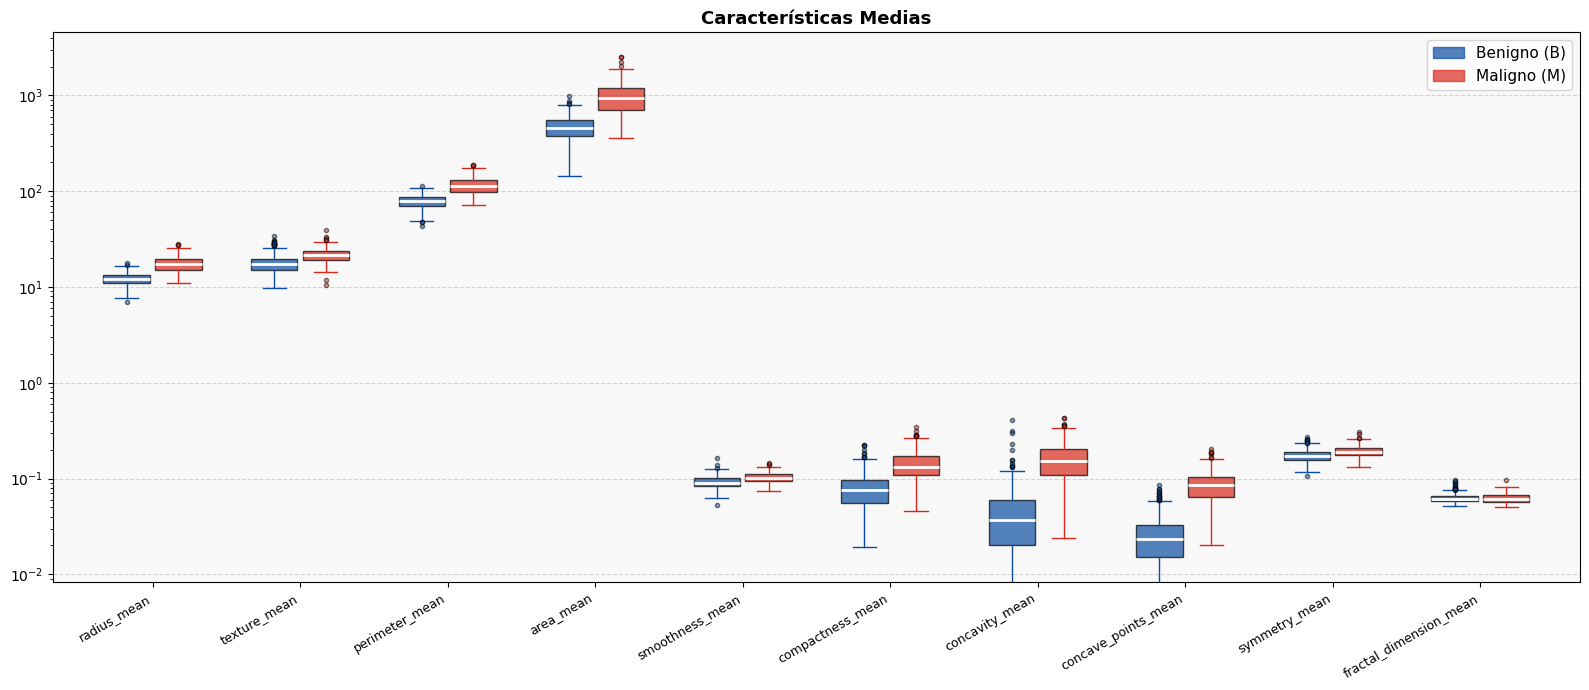

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/01_boxplot_cancer_Error_Estándar.png


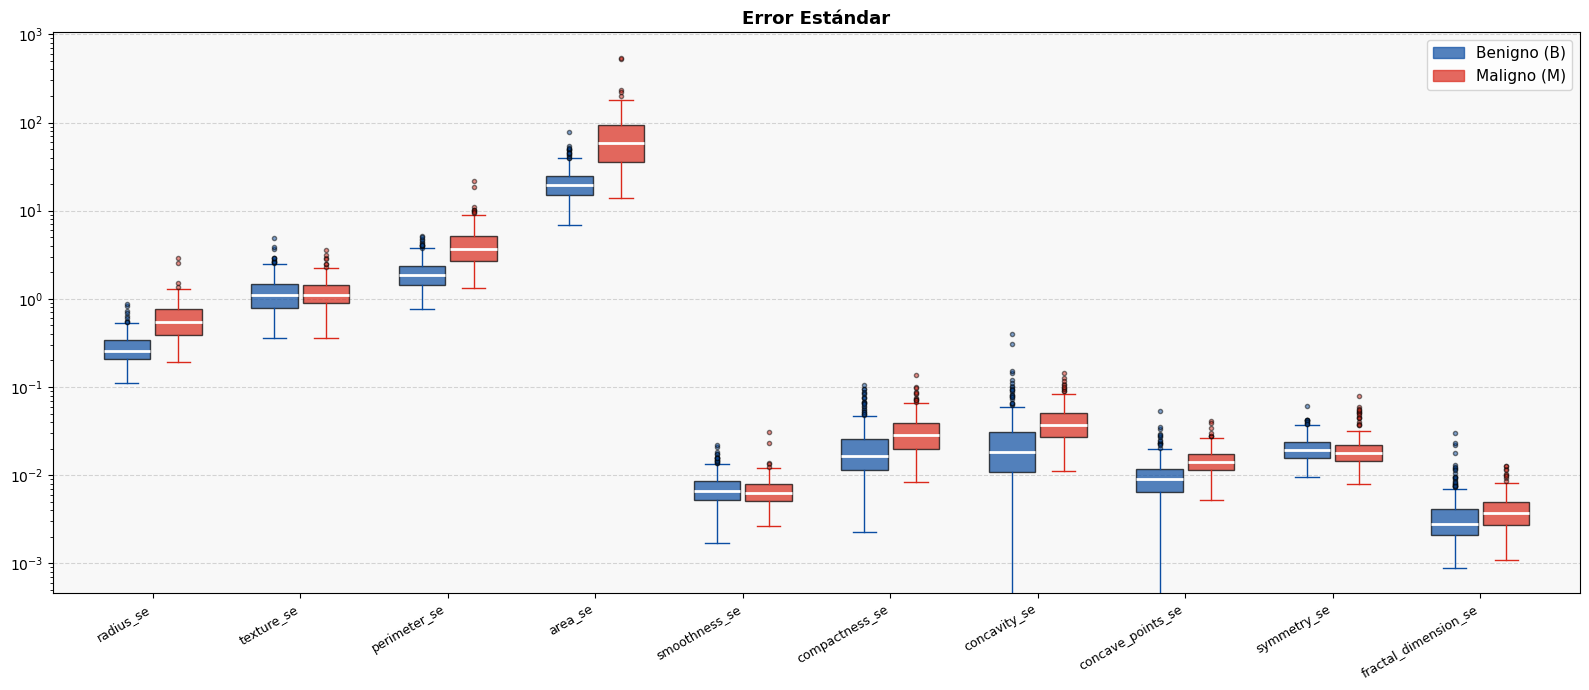

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/01_boxplot_cancer_Valores_Extremos.png


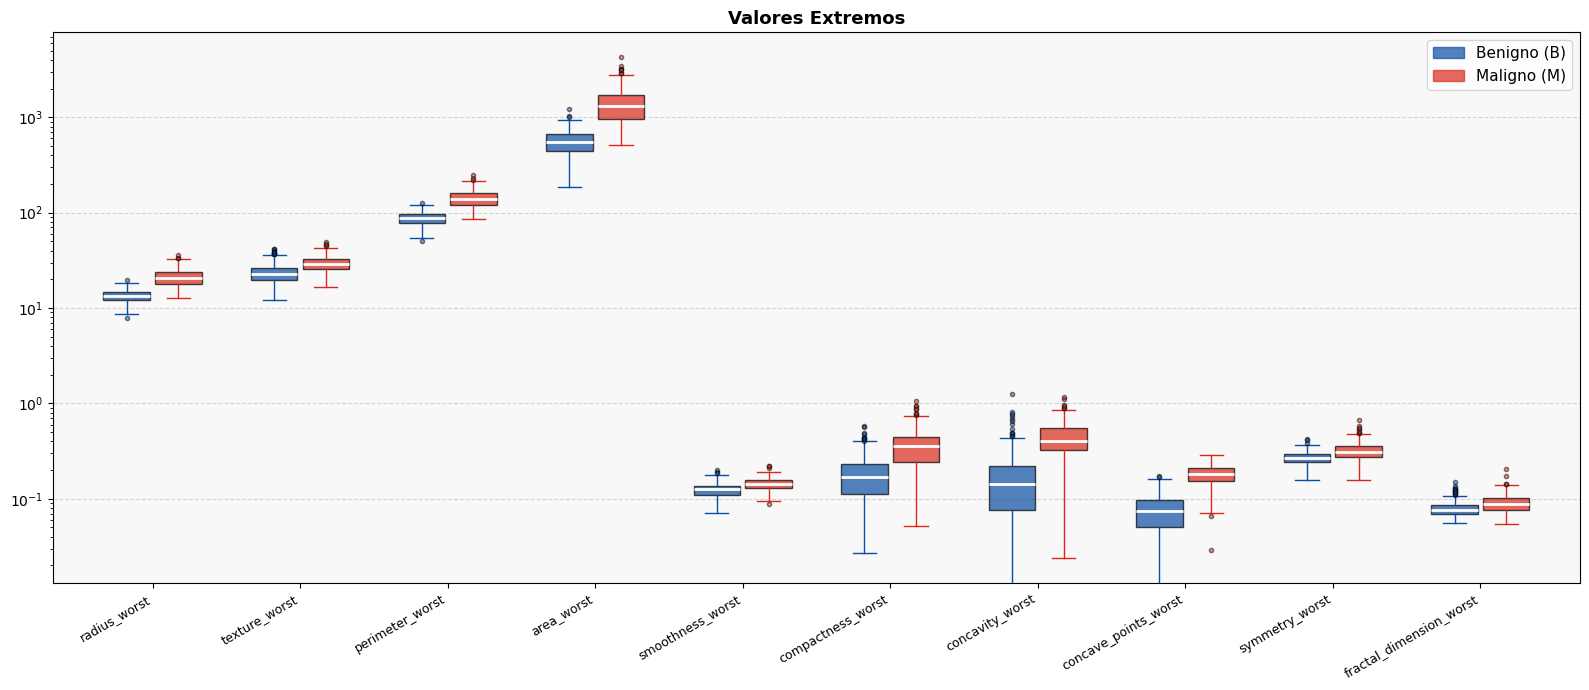

In [11]:
# Boxplots por grupos de características
grupos = [columnas_mean, columnas_se, columnas_worst]

titulos = ['Características Medias', 'Error Estándar', 'Valores Extremos']

for feats, titulo in zip(grupos, titulos):

    fig, ax = plt.subplots(figsize=(16, 7))

    data_B = [df_cancer.loc[df_cancer['diagnosis'] == 'B', f].values for f in feats]

    data_M = [df_cancer.loc[df_cancer['diagnosis'] == 'M', f].values for f in feats]

    x = np.arange(len(feats))
    w = 0.35

    kw_B = dict(patch_artist = True, boxprops = dict(facecolor = AZUL_TELCEL, alpha = 0.7),
        medianprops = dict(color = 'white', linewidth = 2),
        flierprops = dict(marker = 'o', markerfacecolor=AZUL_TELCEL, markersize = 3, alpha = 0.5),
        whiskerprops=dict(color = AZUL_TELCEL),
        capprops=dict(color = AZUL_TELCEL))

    kw_M = dict(patch_artist=True, boxprops=dict(facecolor=ROJO_TECOLOTE, alpha=0.7),
        medianprops=dict(color='white', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor=ROJO_TECOLOTE, markersize=3, alpha=0.5),
        whiskerprops=dict(color=ROJO_TECOLOTE), capprops=dict(color=ROJO_TECOLOTE))

    ax.boxplot(data_B, positions=x - w/2, widths=w * 0.9, **kw_B)
    ax.boxplot(data_M, positions=x + w/2, widths=w * 0.9, **kw_M)
    ax.set_xticks(x)
    ax.set_xticklabels(feats, rotation=30, ha='right', fontsize=9)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_facecolor('#f8f8f8')
    ax.set_yscale('log', base = 10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    handles = [mpatches.Patch( color=AZUL_TELCEL, alpha=0.7, label='Benigno (B)'),
        mpatches.Patch(color=ROJO_TECOLOTE, alpha=0.7, label='Maligno (M)')]

    ax.legend(handles=handles, fontsize=11)
    guardar_figura(f'01_boxplot_cancer_{titulo.replace(" ", "_")}.png')

    plt.tight_layout()
    plt.show()

### 2c) Estandarización de características

Tomamos nuestras características numéricas.

In [12]:
Stdsc = StandardScaler()
cancer_scaled = Stdsc.fit_transform(df_cancer[columnas_num])

### 2d) Separación de datos de entrenamiento y prueba


Ya con nuestra característica `y = diagnosis`, podemos separar los datos con el `train_test_split`. 

In [13]:
X, y = cancer_scaled, df_cancer['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.3, 
                                                    random_state = 43,
                                                    shuffle = True,
                                                    stratify = y)

In [14]:
X_train.shape, y_train.shape

((398, 30), (398,))

### 2e) Manejo de desbalance de clases


Primero se calcula el `ratio` de diagnosis:

In [15]:
# ratio de diagnosis
benigno = df_cancer['diagnosis'] == 'B'
maligno = df_cancer['diagnosis'] == 'M'

if maligno.sum() == 0 or benigno.sum() == 0:

    ratio = 0
    print('No hay casos para calcular el ratio.')

if maligno.sum() >= 0 and benigno.sum() > 0:

    ratio = maligno.sum() / benigno.sum()   

else:

    ratio = benigno.sum() / maligno.sum()

print(f'Casos de diagnosis malignos: {maligno.sum()}')
print(f'Casos de diagnosis benignos: {benigno.sum()}')
print(f'\nRatio: {ratio:.2f}')

Casos de diagnosis malignos: 212
Casos de diagnosis benignos: 357

Ratio: 0.59


En mi opinión, las clases de diagnosis no se encuentran tan desbalanceadas, así que no se debería tomar medidas para el desbalanceo. Pero igualmente voy a aplicar `SMOTE`.

In [16]:
# Sobremuestreo con SMOTE sobre el conjunto de entrenamiento
smote = SMOTE(random_state = 43)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Conteos
antes = pd.Series(y_train).value_counts()
despues = pd.Series(y_train_smote).value_counts()

print(f'Entrenamiento antes:\nB: {antes["B"]:>3}\nM: {antes["M"]:>3}\ntotal: {len(y_train)}')
print(f'\nEntrenamiento después:\nB: {despues["B"]:>3}\nM: {despues["M"]:>3}\ntotal: {len(y_train_smote)}')

Entrenamiento antes:
B: 250
M: 148
total: 398

Entrenamiento después:
B: 250
M: 250
total: 500


### 2f) Visualización de distribución


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/02_distribucion_smote_cancer.png


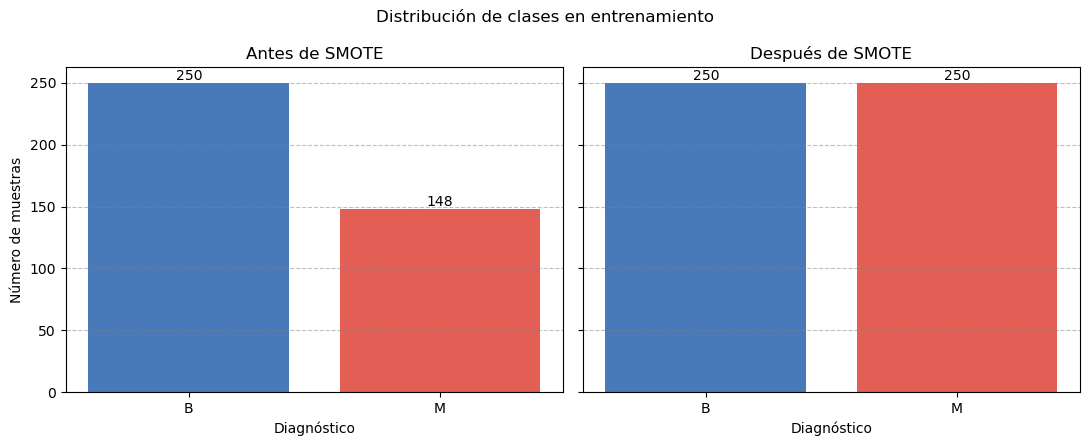

In [17]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize = (11, 4.5), sharey = True)

for ax, conteo, titulo in zip(axes, [antes, despues], ['Antes de SMOTE', 'Después de SMOTE']):

    barras = ax.bar(conteo.index, conteo.values, color = [AZUL_TELCEL, ROJO_TECOLOTE], alpha = 0.75)
    ax.set_title(titulo)
    ax.set_xlabel('Diagnóstico')
    ax.grid(axis = 'y', linestyle = '--', color = 'gray', alpha = 0.5)

    for b, v in zip(barras, conteo.values):

        ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha = 'center', va = 'bottom')

axes[0].set_ylabel('Número de muestras')
plt.suptitle('Distribución de clases en entrenamiento')
plt.tight_layout()
guardar_figura('02_distribucion_smote_cancer.png')
plt.show()

## 3. Reducción de dimensiones por PCA

### 3a) Aplicar PCA a datos balanceados

Se ocupará PCA con `mle`, es decir: Minka's Maximum Likelihood Estimation. Lo que hace esta cosa es inferir la dimensión estadísticamente más plausible.

In [18]:
pesea_mle = PCA(n_components = 'mle', 
            svd_solver = 'full', 
            iterated_power = 'auto',
            n_oversamples =  10,
            power_iteration_normalizer = 'auto',
            random_state = 43)
pesea_mle

,n_components,'mle'
,copy,True
,whiten,False
,svd_solver,'full'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,43


In [19]:
X_pesea_mle = pesea_mle.fit_transform(X_train)
print('Componentes seleccionados por MLE:', pesea_mle.n_components_)

Componentes seleccionados por MLE: 29


In [20]:
pesea_2d = PCA(n_components = 2, random_state = 43)
pesea_2d

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,43


In [21]:
X_pesea_2d = pesea_2d.fit_transform(X_train)

### 3b) Varianza acumulada 

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/03_varianza_acumulada_pesea_mle.png


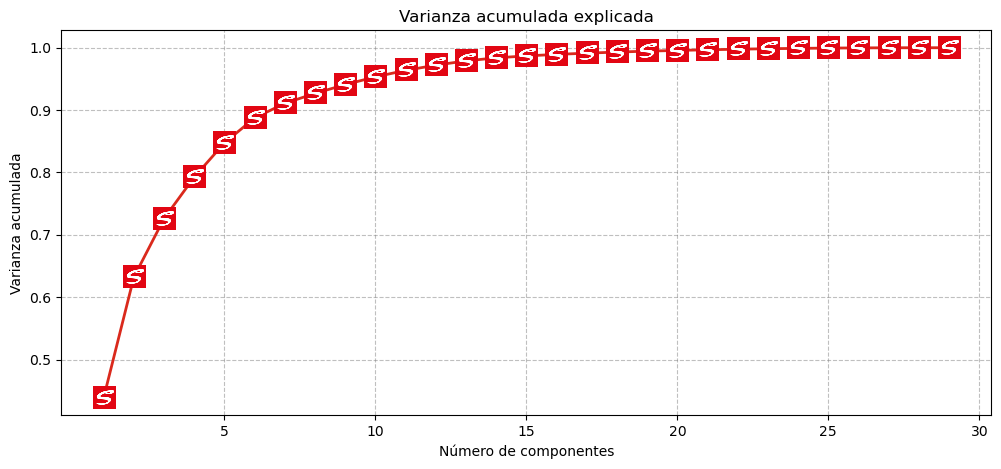

In [22]:
var_ac_mle = np.cumsum(pesea_mle.explained_variance_ratio_)

img = np.array(Image.open(RUTA_SANBORNS).convert('RGBA').resize((80, 80)))

plt.figure(figsize = (12, 5))

plt.plot(range(1, len(var_ac_mle) + 1), var_ac_mle, color = ROJO_TECOLOTE, linewidth = 2)

ax = plt.gca()

for x, y in zip(range(1, len(var_ac_mle) + 1), var_ac_mle):

    oi = OffsetImage(img, zoom = 0.2)
    ab = AnnotationBbox(oi, (x, y), frameon = False)
    ax.add_artist(ab)

plt.xlabel('Número de componentes')
plt.xticks([5, 10, 15, 20, 25, 30])
plt.ylabel('Varianza acumulada')
plt.title('Varianza acumulada explicada')

plt.grid(linestyle = '--', color = 'gray', alpha = 0.5)

guardar_figura('03_varianza_acumulada_pesea_mle.png')

plt.show()

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/04_varianza_acumulada_pesea_2d.png


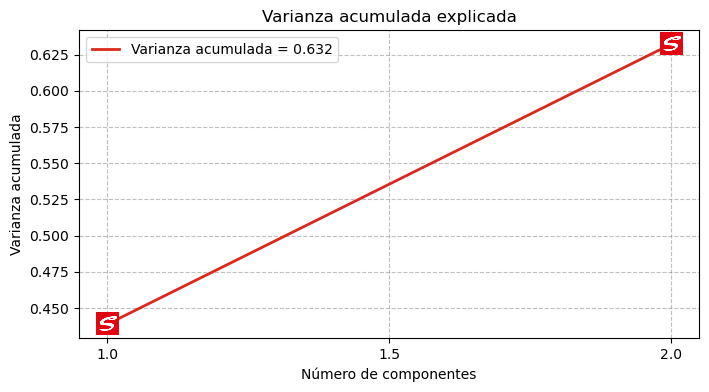

In [23]:
var_ac_2d = np.cumsum(pesea_2d.explained_variance_ratio_)

plt.figure(figsize = (8, 4))

plt.plot(range(1, len(var_ac_2d) + 1), var_ac_2d, color = ROJO_TECOLOTE, linewidth = 2)

ax = plt.gca()

for x, y in zip(range(1, len(var_ac_2d) + 1), var_ac_2d):

    oi = OffsetImage(img, zoom = 0.2)
    ab = AnnotationBbox(oi, (x, y), frameon = False)
    ax.add_artist(ab)
plt.xlabel('Número de componentes')
plt.xticks([1, 1.5, 2])
plt.ylabel('Varianza acumulada')
plt.legend(['Varianza acumulada = {}'.format(var_ac_2d[-1].round(3))])
plt.title('Varianza acumulada explicada')

plt.grid(linestyle = '--', color = 'gray', alpha = 0.5)

guardar_figura('04_varianza_acumulada_pesea_2d.png')

plt.show()

### 3c) Componentes para el 95% de varianza

In [24]:
pesea_var_95 = PCA(n_components = 0.95, random_state = 43)
pesea_var_95

,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,43


In [25]:
X_pesea_var_95 = pesea_var_95.fit_transform(X_train)
print(pesea_var_95.n_components_)

10


### 3d) Visualización de componentes principales y varianza acumulada

Empezemos con el intento de tener dos componentes:

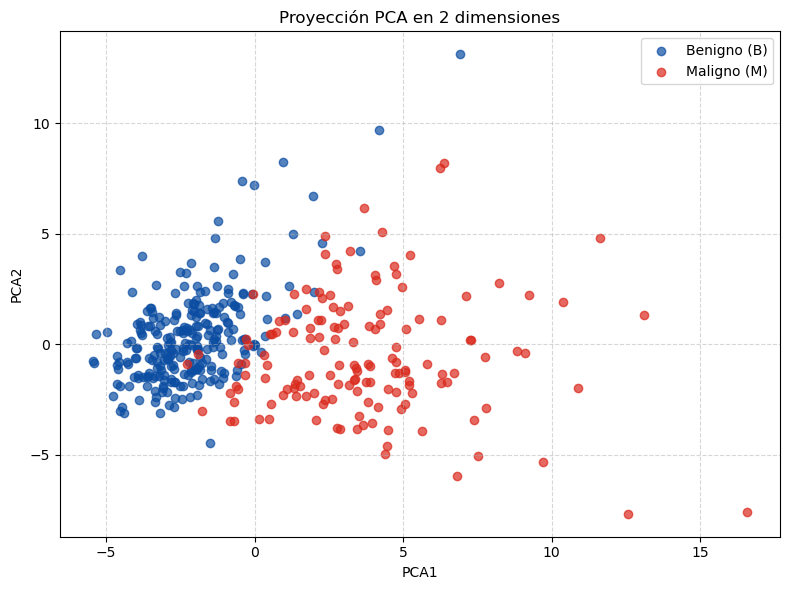

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/05_pca_2d.png


<Figure size 640x480 with 0 Axes>

In [26]:
fig = plt.figure(figsize = (8, 6))
plt.scatter(X_pesea_2d[y_train == 'B', 0], X_pesea_2d[y_train == 'B', 1], color = AZUL_TELCEL, alpha = 0.7, label = 'Benigno (B)')
plt.scatter(X_pesea_2d[y_train == 'M', 0], X_pesea_2d[y_train == 'M', 1], color = ROJO_TECOLOTE, alpha = 0.7, label = 'Maligno (M)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Proyección PCA en 2 dimensiones')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

guardar_figura('05_pca_2d.png')

Seguimos con el 95% de varianza:

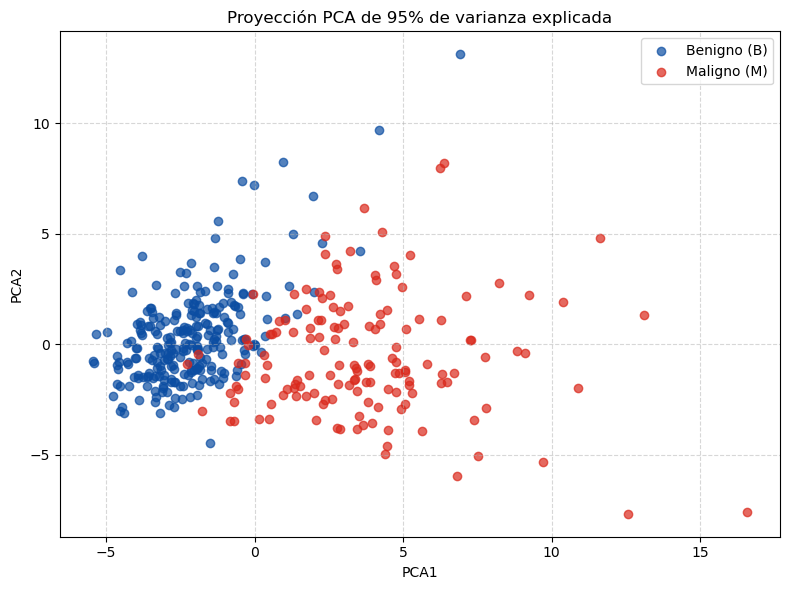

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/06_pca_var_95.png


<Figure size 640x480 with 0 Axes>

In [27]:
fig = plt.figure(figsize = (8, 6))
plt.scatter(X_pesea_var_95[y_train == 'B', 0], X_pesea_var_95[y_train == 'B', 1], 
            color = AZUL_TELCEL, alpha = 0.7, label = 'Benigno (B)')

plt.scatter(X_pesea_var_95[y_train == 'M', 0], X_pesea_var_95[y_train == 'M', 1], 
            color = ROJO_TECOLOTE, alpha = 0.7, label = 'Maligno (M)')

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Proyección PCA de 95% de varianza explicada')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

guardar_figura('06_pca_var_95.png')

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/07_pca_10_componentes.png


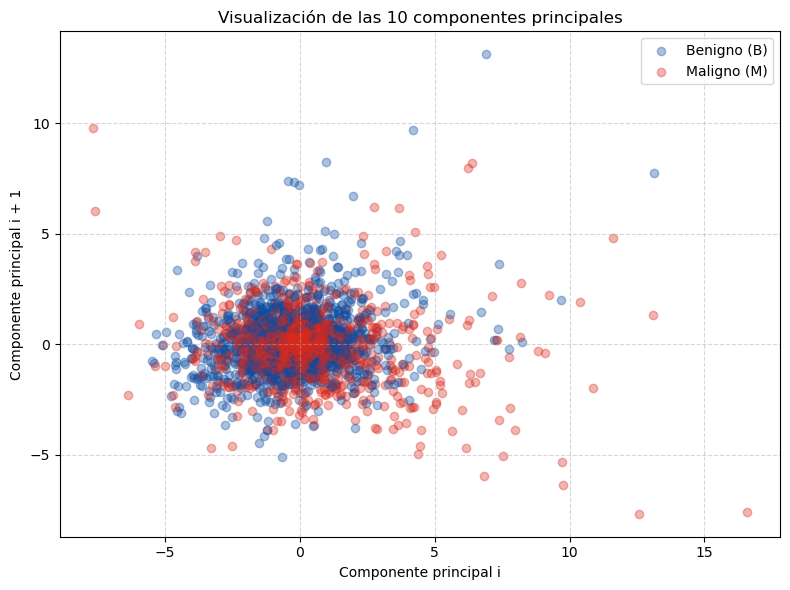

In [28]:
fig = plt.figure(figsize = (8, 6))

for i in range(1, pesea_var_95.n_components_):

    plt.scatter(X_pesea_var_95[y_train == 'B', i - 1], X_pesea_var_95[y_train == 'B', i], 
        color = AZUL_TELCEL, alpha = 0.35)

    plt.scatter(X_pesea_var_95[y_train == 'M', i - 1], X_pesea_var_95[y_train == 'M', i], 
                color = ROJO_TECOLOTE, alpha = 0.35)

plt.xlabel('Componente principal i')
plt.ylabel('Componente principal i + 1')

plt.title(f'Visualización de las {pesea_var_95.n_components_} componentes principales')

plt.legend(['Benigno (B)', 'Maligno (M)'])

plt.grid(linestyle = '--', alpha = 0.5)

plt.tight_layout()

guardar_figura('07_pca_10_componentes.png')

plt.show()

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/08_varianza_acumulada_pesea_var_95.png


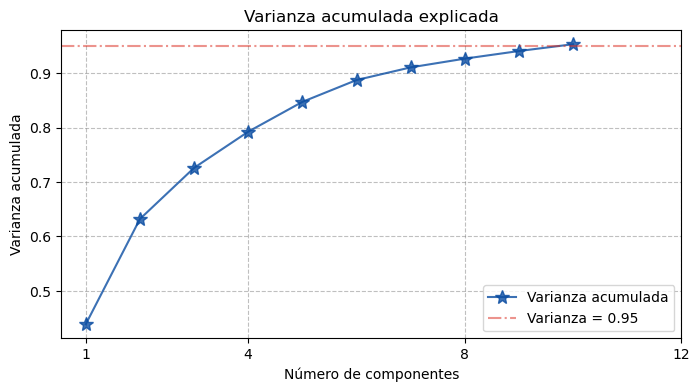

In [29]:
var_ac95 = np.cumsum(pesea_var_95.explained_variance_ratio_)

plt.figure(figsize = (8, 4))

plt.plot(range(1, len(var_ac95) + 1), var_ac95, marker = '*', markersize = 10, color = AZUL_TELCEL, alpha = 0.8)
plt.axhline(y = 0.95, linestyle = '-.', alpha = 0.5, color = ROJO_TECOLOTE)
plt.xlabel('Número de componentes')
plt.xticks([1, 4, 8, 12])
plt.ylabel('Varianza acumulada')
plt.title('Varianza acumulada explicada')
plt.legend(labels = ['Varianza acumulada', 'Varianza = 0.95'])
plt.grid(linestyle = '--', color = 'gray', alpha = 0.5)
guardar_figura('08_varianza_acumulada_pesea_var_95.png')
plt.show()